In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4 as nc
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from wrf import (to_np, getvar, get_cartopy, latlon_coords)
import cartopy.crs as crs
import numpy as np

In [18]:
data = nc.Dataset("E:/000_FuJian/wrfout_FuJian/A1_mp8_cu0/1wrfout_d03.nc")

In [19]:
u = getvar(data, 'U10')
v = getvar(data, 'V10')
u_t1 = u.values
v_t1 = v.values
print(u_t1[0,0]) #-10.800997
print(v_t1[0,0]) #-1.5048263
print(np.sqrt(u_t1[0,0]**2+v_t1[0,0]**2)) #10.905321

-0.5818053
1.2011681
1.334654300992349


In [20]:
uv = getvar(data, 'uvmet10')
u_t2 = uv.values[0]
v_t2 = uv.values[1]
print(u_t2[0,0]) #-10.743759
print(v_t2[0,0]) #-1.8702047
print(np.sqrt(u_t2[0,0]**2+v_t2[0,0]**2)) #10.905321
# Retrieve latitude and longitude coordinates
lats, lons = latlon_coords(u)

# Create a grid of longitude and latitude
lons1, lats1 = np.meshgrid(lons, lats)
#lons1, lats1 = latlon_coords(u)
#lons2, lats2 = latlon_coords(uv)
print(lons2)

-0.59337157
1.1954967
1.3346543103615647
<xarray.DataArray 'XLAT' (south_north: 195, west_east: 255)>
array([[25.122063, 25.122147, 25.12223 , ..., 25.12223 , 25.122147,
        25.122063],
       [25.131035, 25.131126, 25.131203, ..., 25.131203, 25.131126,
        25.131035],
       [25.140045, 25.140114, 25.140205, ..., 25.140205, 25.140114,
        25.140045],
       ...,
       [26.848873, 26.84895 , 26.849052, ..., 26.849052, 26.84895 ,
        26.848873],
       [26.857857, 26.857952, 26.858032, ..., 26.858032, 26.857952,
        26.857857],
       [26.866856, 26.866947, 26.86702 , ..., 26.86702 , 26.866947,
        26.866856]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 117.9 117.9 118.0 ... 120.5 120.5
    XLAT     (south_north, west_east) float32 25.12 25.12 25.12 ... 26.87 26.87
    XTIME    float32 0.0
    Time     datetime64[ns] 2024-04-04
Dimensions without coordinates: south_north, west_east


ValueError: The shapes of the passed in arrays do not match

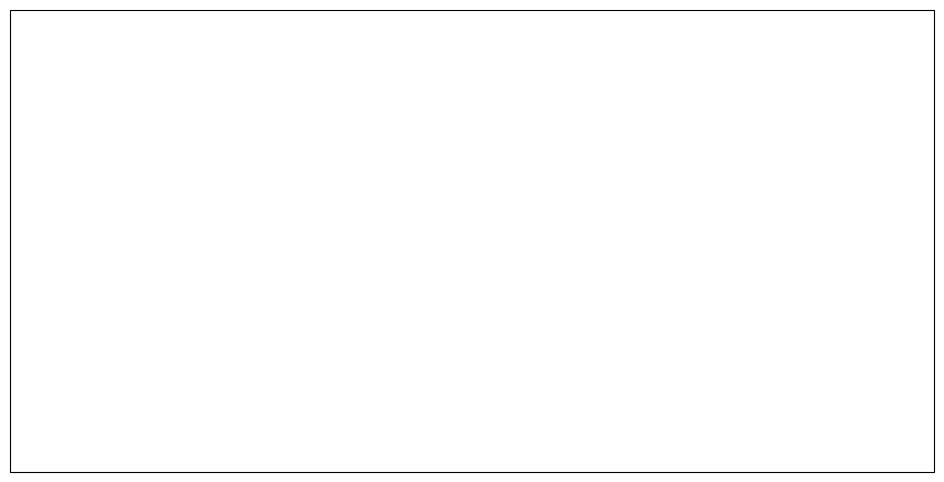

In [21]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

mesh = ax.barbs(lons1[::3,::3], lats1[::3,::3], u_t1[::3,::3],v_t1[::3,::3],color='r', linewidth=0.7)
ax.barbs(lons2[::3,::3], lats2[::3,::3], u_t2[::3,::3],v_t2[::3,::3],color='b', linewidth=0.7)
mesh = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.6, alpha=0.5, x_inline=False, y_inline=False, color='k')
mesh.top_labels=False
mesh.right_labels=False
mesh.xformatter = LONGITUDE_FORMATTER
mesh.yformatter = LATITUDE_FORMATTER
plt.show()


In [ ]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

mesh = ax.barbs(lons1[::5,::5], lats1[::5,::5], u_t1[::5,::5],v_t1[::5,::5],color='k', linewidth=0.7)
#mesh = ax.barbs(lons1[::1,::1], lats1[::1,::1], u_t1[::1,::1],v_t1[::1,::1],color='k', linewidth=0.7)
mesh = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.6, alpha=0.5, x_inline=False, y_inline=False, color='k')
mesh.top_labels=False
mesh.right_labels=False
mesh.xformatter = LONGITUDE_FORMATTER
mesh.yformatter = LATITUDE_FORMATTER
ax.set_extent([115.5,120.5,23.5,28.5],crs=ccrs.PlateCarree())


In [ ]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

mesh = ax.quiver(lons1[::3,::3], lats1[::3,::3], u_t1[::3,::3],v_t1[::3,::3],color='k')
mesh = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.6, alpha=0.5, x_inline=False, y_inline=False, color='k')
mesh.top_labels=False
mesh.right_labels=False
mesh.xformatter = LONGITUDE_FORMATTER
mesh.yformatter = LATITUDE_FORMATTER

ax.set_extent([113,115.5,21.5,23.5],crs=ccrs.PlateCarree())